In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("../data/NF-UNSW-NB15-v3.csv")

In [6]:
df.shape
display(df.columns.tolist())
display(df.head(3))

['FLOW_START_MILLISECONDS',
 'FLOW_END_MILLISECONDS',
 'IPV4_SRC_ADDR',
 'L4_SRC_PORT',
 'IPV4_DST_ADDR',
 'L4_DST_PORT',
 'PROTOCOL',
 'L7_PROTO',
 'IN_BYTES',
 'IN_PKTS',
 'OUT_BYTES',
 'OUT_PKTS',
 'TCP_FLAGS',
 'CLIENT_TCP_FLAGS',
 'SERVER_TCP_FLAGS',
 'FLOW_DURATION_MILLISECONDS',
 'DURATION_IN',
 'DURATION_OUT',
 'MIN_TTL',
 'MAX_TTL',
 'LONGEST_FLOW_PKT',
 'SHORTEST_FLOW_PKT',
 'MIN_IP_PKT_LEN',
 'MAX_IP_PKT_LEN',
 'SRC_TO_DST_SECOND_BYTES',
 'DST_TO_SRC_SECOND_BYTES',
 'RETRANSMITTED_IN_BYTES',
 'RETRANSMITTED_IN_PKTS',
 'RETRANSMITTED_OUT_BYTES',
 'RETRANSMITTED_OUT_PKTS',
 'SRC_TO_DST_AVG_THROUGHPUT',
 'DST_TO_SRC_AVG_THROUGHPUT',
 'NUM_PKTS_UP_TO_128_BYTES',
 'NUM_PKTS_128_TO_256_BYTES',
 'NUM_PKTS_256_TO_512_BYTES',
 'NUM_PKTS_512_TO_1024_BYTES',
 'NUM_PKTS_1024_TO_1514_BYTES',
 'TCP_WIN_MAX_IN',
 'TCP_WIN_MAX_OUT',
 'ICMP_TYPE',
 'ICMP_IPV4_TYPE',
 'DNS_QUERY_ID',
 'DNS_QUERY_TYPE',
 'DNS_TTL_ANSWER',
 'FTP_COMMAND_RET_CODE',
 'SRC_TO_DST_IAT_MIN',
 'SRC_TO_DST_IAT_MAX',
 

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign


In [7]:
display(df[['FLOW_START_MILLISECONDS','FLOW_END_MILLISECONDS','Attack']].dtypes)
display(df[['FLOW_START_MILLISECONDS','FLOW_END_MILLISECONDS','Attack']].isnull().sum())

FLOW_START_MILLISECONDS     int64
FLOW_END_MILLISECONDS       int64
Attack                     object
dtype: object

FLOW_START_MILLISECONDS    0
FLOW_END_MILLISECONDS      0
Attack                     0
dtype: int64

In [8]:
attack_counts = df['Attack'].value_counts()
print(attack_counts)

Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64


In [9]:
classes = ['Benign', 'Fuzzers', 'Exploits', 'Backdoor',
           'Reconnaissance', 'Generic', 'DoS', 'Shellcode', 'Analysis', 'Worms']

In [10]:
df['FLOW_DURATION_S'] = (df['FLOW_END_MILLISECONDS'] - df['FLOW_START_MILLISECONDS']) / 1000.0

In [11]:
bins = np.linspace(0, 120, 51)

## FLOW LENGTH DURATION

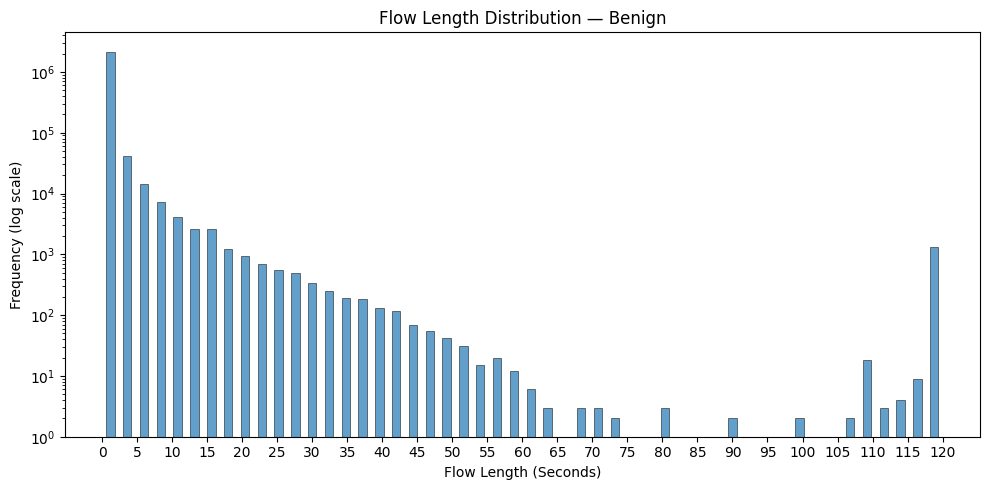

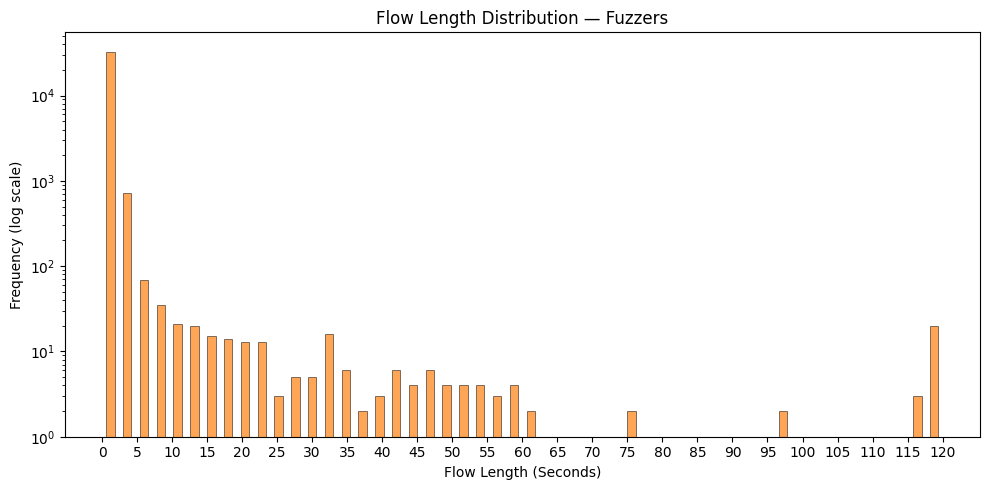

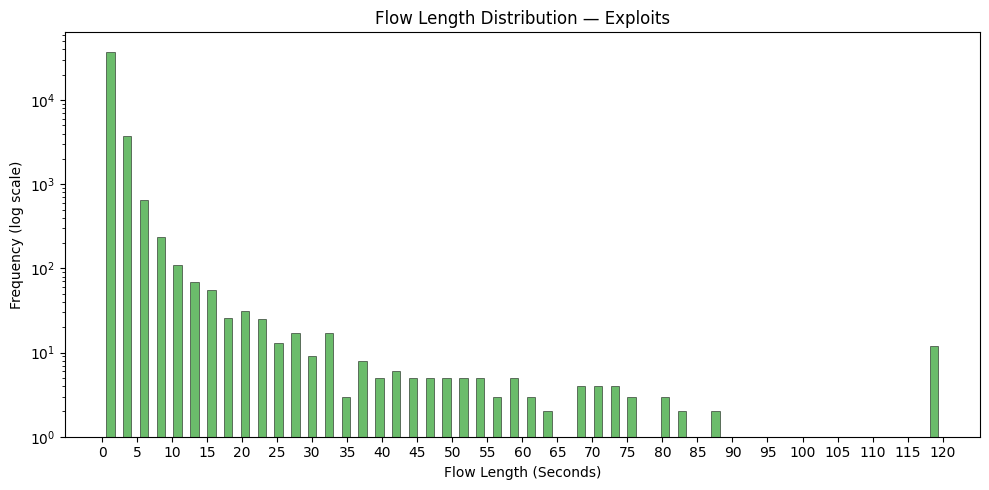

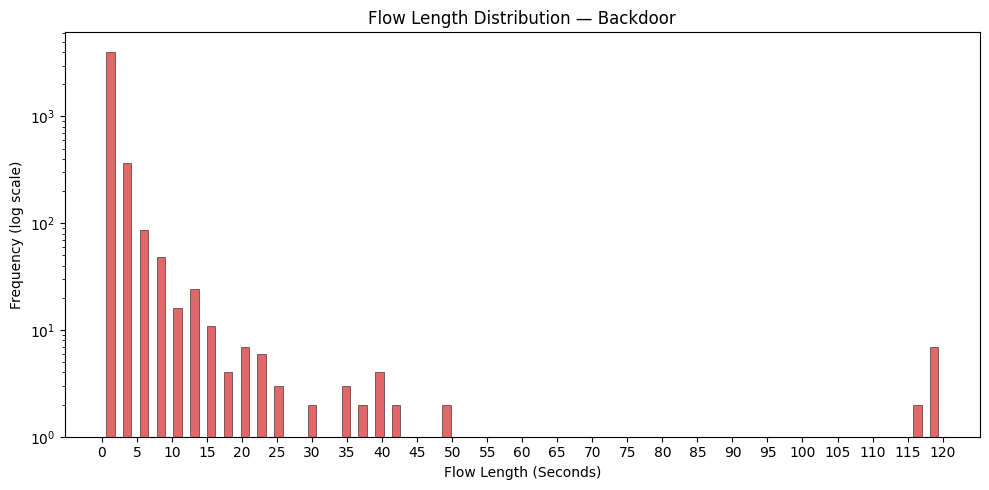

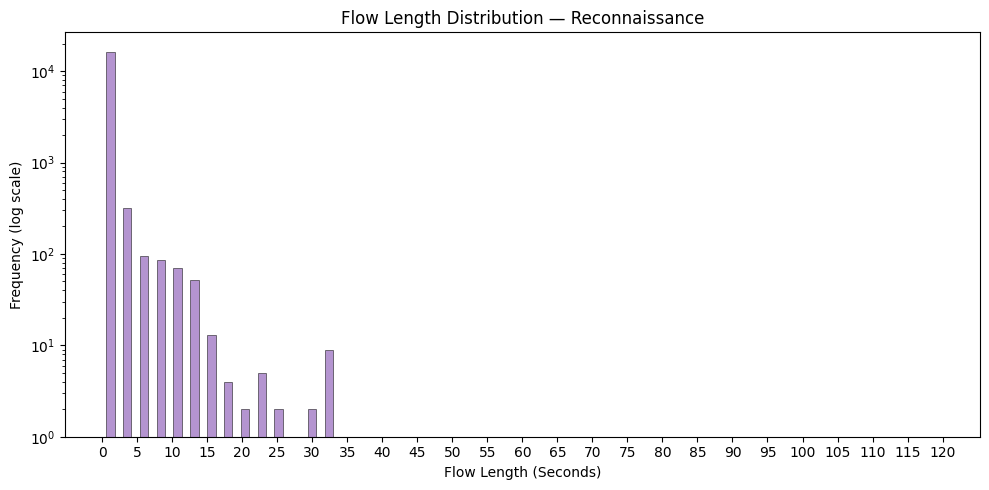

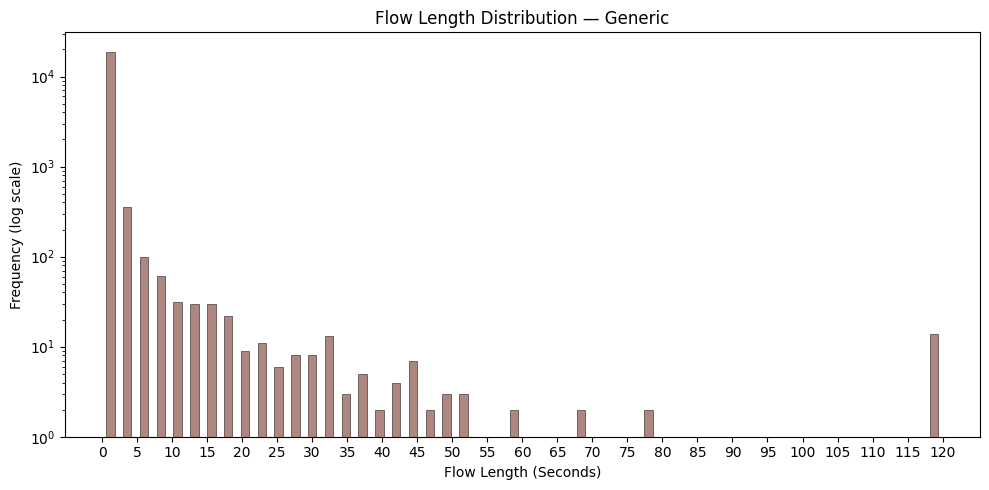

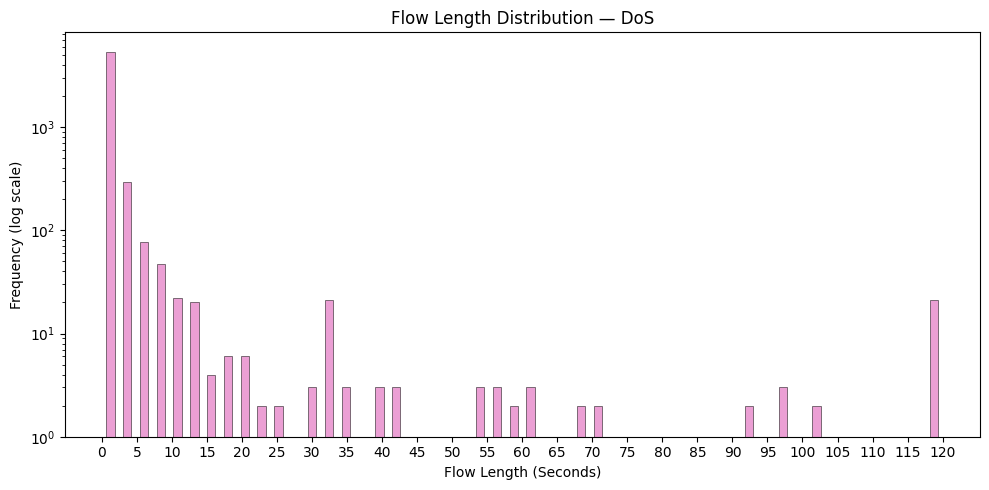

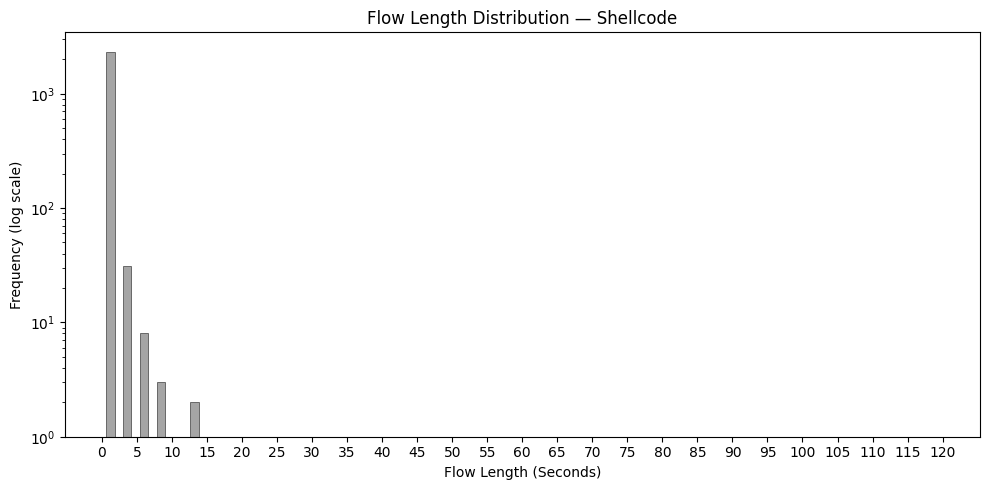

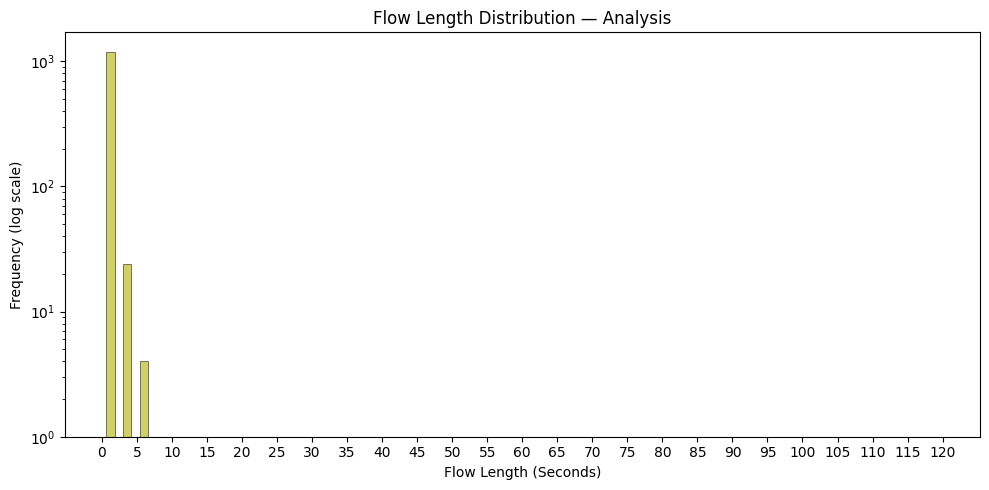

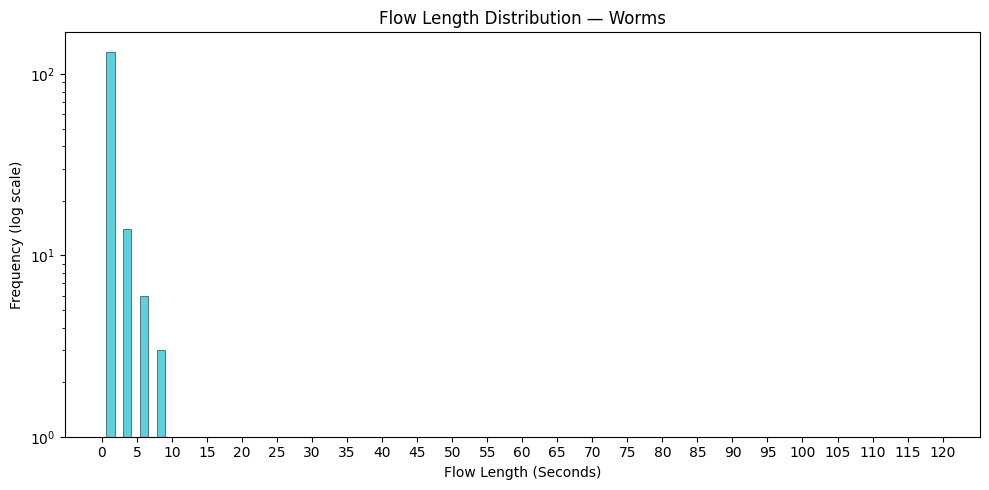

In [12]:
colors = plt.cm.tab10.colors

for i, cls in enumerate(classes):
    subset = df[df['Attack'] == cls]['FLOW_DURATION_S'].clip(0, 120)

    plt.figure(figsize=(10,5))
    plt.hist(subset, bins=bins, rwidth=0.5, alpha=0.7, color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)

    plt.yscale('log')
    plt.ylim(1, None)
    plt.xlabel("Flow Length (Seconds)")
    plt.ylabel("Frequency (log scale)")
    plt.xticks(np.arange(0, 125, 5))
    plt.title(f"Flow Length Distribution — {cls}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [13]:
df['SRC_TO_DST_IAT_AVG_sec'] = df['SRC_TO_DST_IAT_AVG'] / 1000.0

In [14]:
df_zero_counts = df[df['SRC_TO_DST_IAT_AVG_sec'] == 0].groupby('Attack').size()
print(df_zero_counts)

Attack
Backdoor             1239
Benign            1197750
DoS                   959
Exploits             4143
Fuzzers              8232
Generic             14928
Reconnaissance       5787
Shellcode             796
Worms                  22
dtype: int64


In [15]:
bins = np.arange(0, 61, 1)

colors = plt.cm.tab10.colors

## INTER-PACKET ARRIVAL TIME

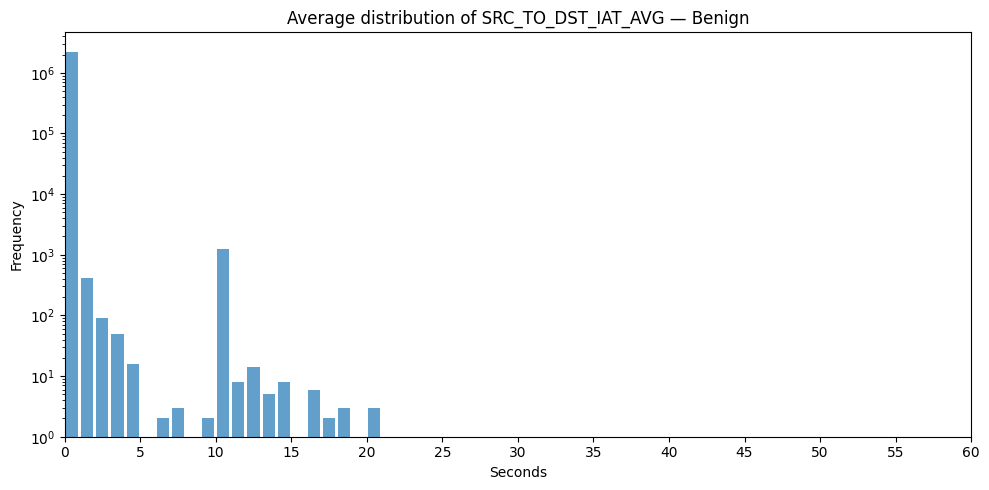

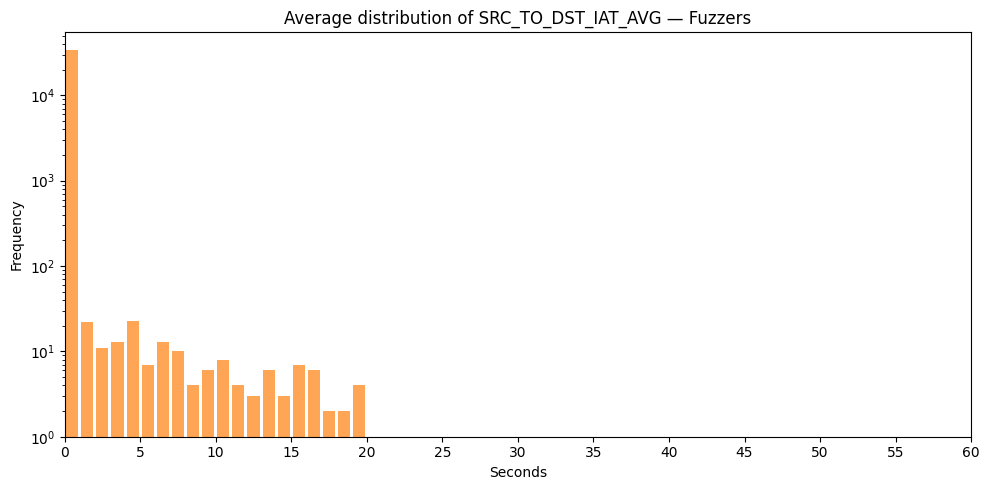

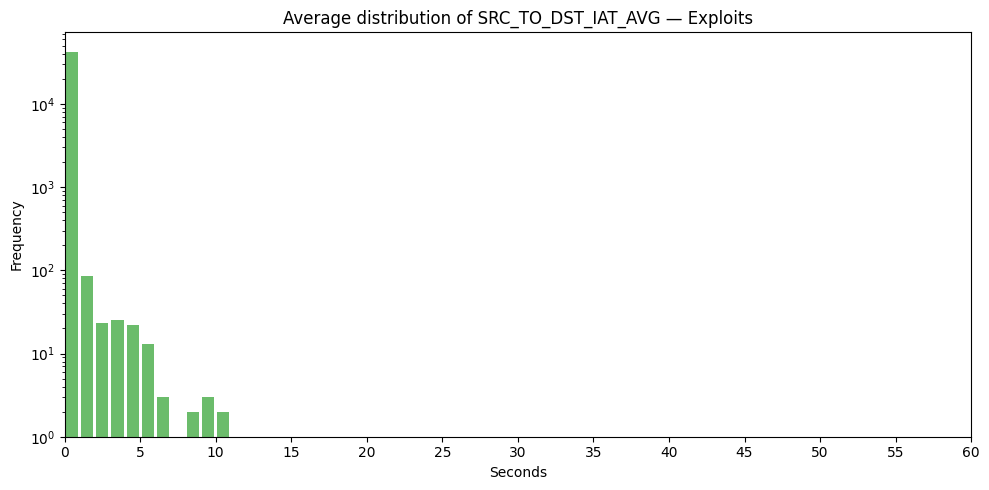

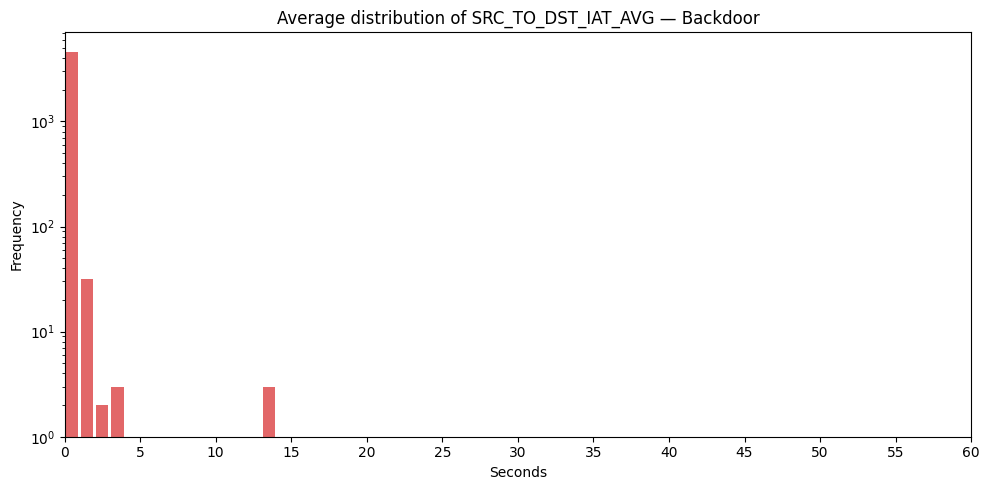

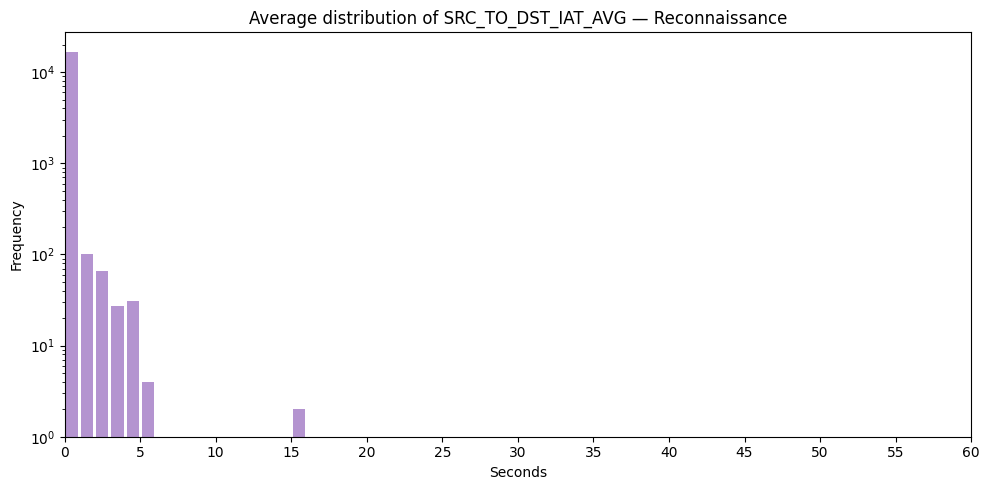

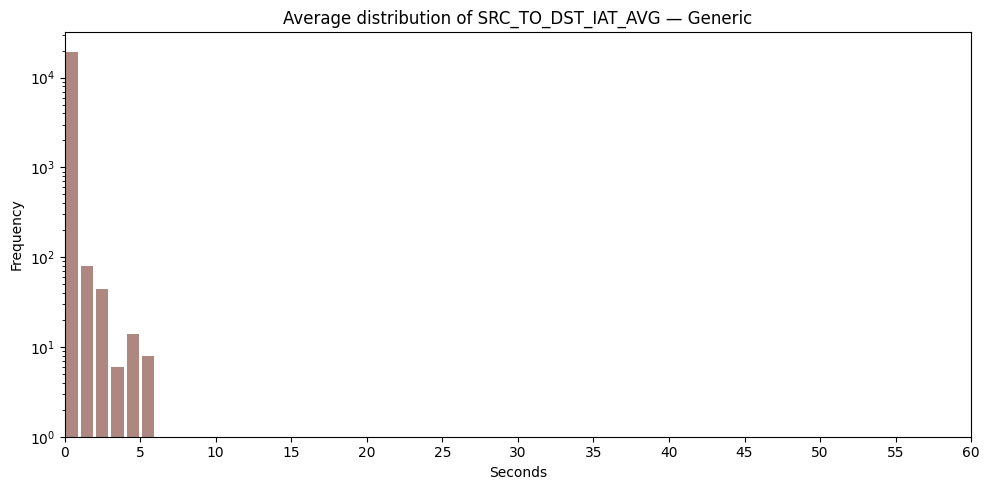

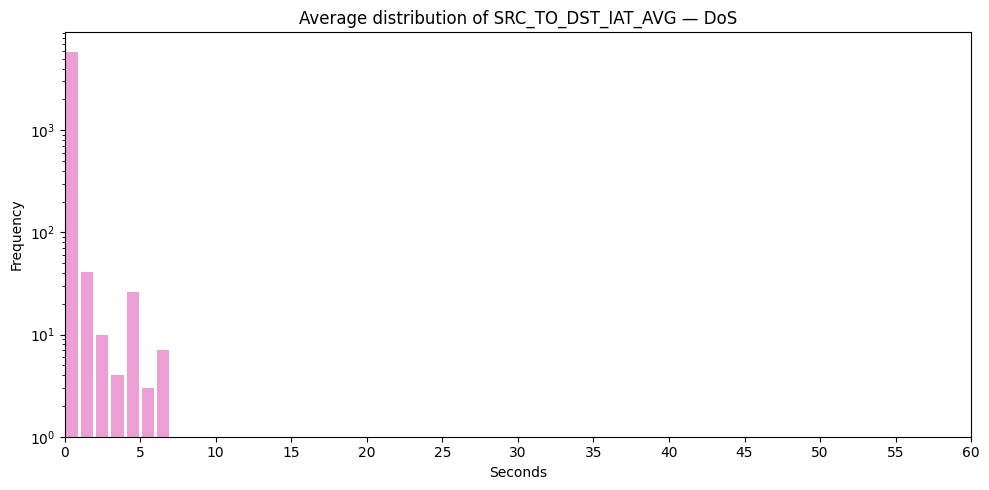

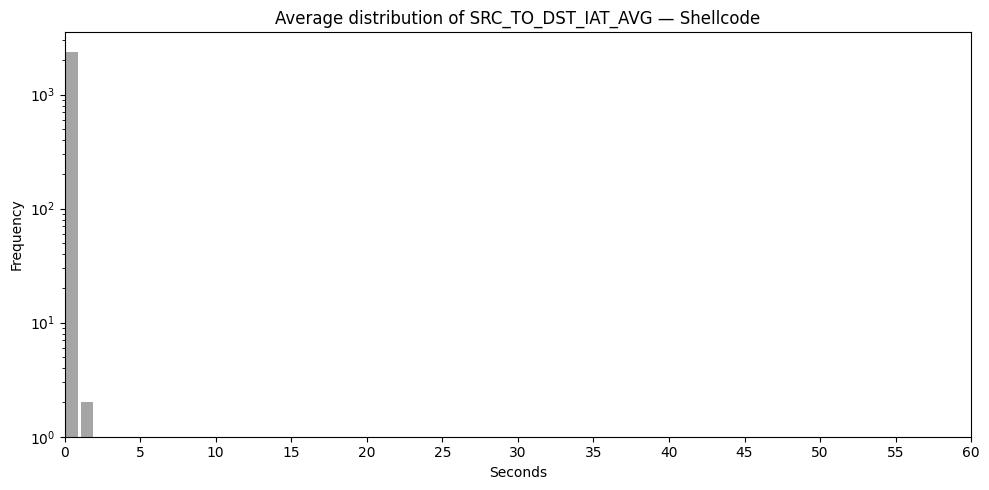

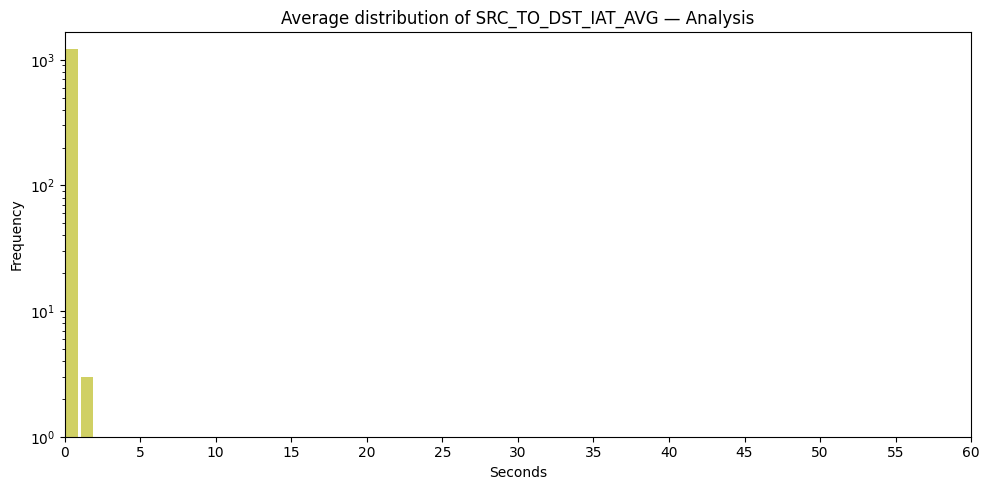

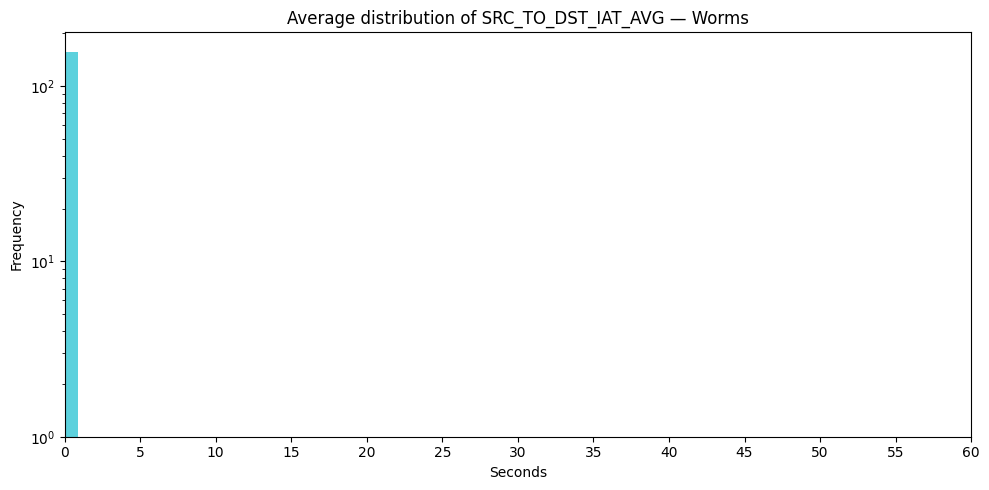

In [16]:
for i, cls in enumerate(classes):

    subset = df[df['Attack'] == cls]['SRC_TO_DST_IAT_AVG_sec']
    if subset.empty:
        continue

    plt.figure(figsize=(10, 5))
    plt.hist(
        subset,
        color=colors[i % len(colors)],
        bins=bins,
        alpha=0.7,
        rwidth=0.8
    )

    plt.yscale('log')
    plt.xlabel("Seconds")
    plt.ylabel("Frequency")
    plt.title(f"Average distribution of SRC_TO_DST_IAT_AVG — {cls}")
    plt.xticks(np.arange(0, 61, 5))
    plt.xlim(0, 60)
    plt.ylim(1, None)
    plt.tight_layout()
    plt.show()